<a href="https://colab.research.google.com/github/charulega/cnn-mask-detection/blob/main/CNN_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Opening Camera... Show your face and click 'Capture Frame'.
 RESULT: NO MASK DETECTED


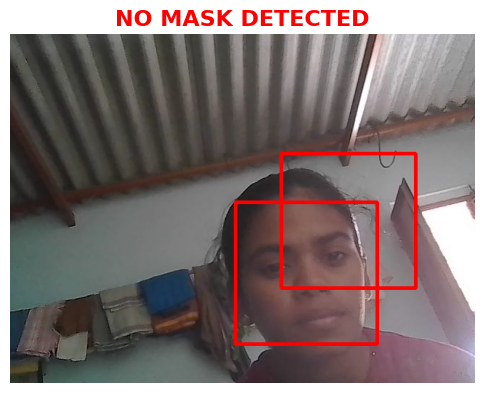

In [ ]:
import numpy as np
from google.colab.output import eval_js
import cv2
from base64 import b64decode
import matplotlib.pyplot as plt


def take_photo(filename='/content/photo.jpg', quality=0.8):
  js = """
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const video = document.createElement('video');
      const button = document.createElement('button');
      button.textContent = 'Capture Frame';
      button.style.padding = '10px 20px'; button.style.fontSize = '16px';
      button.style.backgroundColor = '#4CAF50'; button.style.color = 'white';
      button.style.border = 'none'; button.style.cursor = 'pointer';

      div.appendChild(video); div.appendChild(document.createElement('br'));
      div.appendChild(button); document.body.appendChild(div);

      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      video.srcObject = stream;
      await video.play();

      await new Promise((resolve) => button.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth; canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);

      stream.getTracks().forEach(track => track.stop());
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
  """
  eval_js(js)
  data = eval_js(f'takePhoto({quality})')
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename


try:
  print(" Opening Camera... Show your face and click 'Capture Frame'.")
  filename = take_photo()


  img = cv2.imread(filename)
  rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


  face_cascade_url = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml"

  import urllib.request
  urllib.request.urlretrieve(face_cascade_url, "face.xml")
  face_detector = cv2.CascadeClassifier("face.xml")


  faces = face_detector.detectMultiScale(gray_img, 1.1, 4)


  if len(faces) == 0:
      print(" RESULT: MASK DETECTED")
      result_text = "MASK DETECTED"
      text_color = "green"
  else:
      print(" RESULT: NO MASK DETECTED")
      result_text = "NO MASK DETECTED"
      text_color = "red"

      for (x, y, w, h) in faces:
          cv2.rectangle(rgb_img, (x, y), (x+w, y+h), (255, 0, 0), 3)


  plt.figure(figsize=(6,6))
  plt.imshow(rgb_img)
  plt.title(result_text, color=text_color, fontsize=16, fontweight='bold')
  plt.axis('off')
  plt.show()

except Exception as e:
  print("Pipeline error:", e)